<div style="background: linear-gradient(135deg, #0d0d0d, #1a1a2e, #16213e);
            padding: 36px; border-radius: 16px; text-align: center; font-family: Georgia, serif;">

  <h1 style="color: #f0e6d3; font-size: 36px; margin: 0; letter-spacing: 2px;">
    🎯 FocusIQ v3
  </h1>

  <p style="color: #cfcfcf; font-size: 15px; margin: 12px 0 6px 0;">
    Why do we lose focus even when we want to study?
  </p>

  <p style="color: #a0c4ff; font-size: 14px; margin: 0;">
    FocusIQ analyzes self-reportable daily habits to predict focus level and
    procrastination risk.
  </p>

</div>

<div style="margin-top:18px; font-family:'Segoe UI',sans-serif; max-width:760px; color:#e0e0e0;">

<p style="font-size:14px;">
<b>What changed in v3:</b> the previous version's <code>focus_score</code> target was a
deterministic formula built directly from the same features the model then trained on —
the model was just re-deriving that formula, not learning a real pattern. This version:
</p>

<ul style="line-height:1.8; font-size:14px;">
  <li>Uses <b>real student records</b> (UCI Student Performance dataset) for structural features
      like past failures, free time, going out, family relationships, and absences</li>
  <li>Adds self-reportable habit features (sleep, phone usage, stress, motivation) with realistic
      noise and loose real-world correlations — not pure random noise, not exact formulas</li>
  <li>Grounds <code>focus_score</code> partly in real academic outcomes (G1/G2 grades) that are
      <b>excluded from the model's input features</b>, plus genuine random noise, so the model
      has to actually generalize rather than reverse a formula</li>
  <li>Drops the Google Colab / Drive dependency so this runs anywhere</li>
</ul>

</div>


---
## 📦 Part 1 — Setup & Libraries

In [1]:
# ─────────────────────────────────────────────────────────────────
#  Imports
# ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries loaded!")

✅ All libraries loaded!


---
## 📊 Part 2 — Dataset: Real Features + Grounded Simulation

Source: **UCI Student Performance dataset** (`student-mat.csv`, 395 students, semicolon-delimited).

**Real columns used directly** (not invented): `failures`, `freetime`, `goout`, `famrel`,
`absences`, `studytime` (mapped to honest hour ranges — it's an ordinal bucket, not a precise
number), `health` (renamed `health_status`).

**Self-reportable habit features simulated** (the source dataset has no wellness/focus survey,
so these don't exist in real data): `sleep_hours`, `phone_usage_hrs`, `stress_level`,
`motivation_level`, `exercise_done`. Each is built with a *loose* real-world correlation to a
real column plus meaningful random noise — e.g. more time going out → less sleep, on average,
with individual variation — instead of being pure independent noise.

**Target (`focus_score`)** is grounded partly in real G1/G2 grades (as a proxy for baseline
ability to stay on task) *plus* the habit features *plus* random noise — and G1/G2 are excluded
from the model's training features, so the model must learn from self-reportable inputs alone,
same as a real user would provide.

In [1]:
# ─────────────────────────────────────────────────────────────────
#  Load real data (note: semicolon-delimited, not comma)
# ─────────────────────────────────────────────────────────────────
df = pd.read_csv("student-mat.csv", sep=";")
print("Loaded:", df.shape)

Loaded: (395, 33)


In [1]:
# ─────────────────────────────────────────────────────────────────
#  Real features, honestly interpreted
# ─────────────────────────────────────────────────────────────────

# studytime is an ORDINAL bucket (1=<2h, 2=2-5h, 3=5-10h, 4=>10h) -> map to
# honest midpoint hours instead of pretending it's precise
studytime_map = {1: 1.5, 2: 3.5, 3: 7.5, 4: 10.0}
df['study_hours']   = df['studytime'].map(studytime_map)
df['health_status'] = df['health']   # 1 (bad) - 5 (good), real
# failures, freetime, goout, famrel, absences already have honest names

print("✅ Real features mapped")

✅ Real features mapped


In [1]:
# ─────────────────────────────────────────────────────────────────
#  Simulated self-report features (grounded, not pure noise)
# ─────────────────────────────────────────────────────────────────
n = len(df)

df['sleep_hours'] = np.clip(
    7.5 - 0.3 * df['goout'] + 0.3 * df['health_status']
    + np.random.normal(0, 1.1, n), 3, 10
)

df['phone_usage_hrs'] = np.clip(
    2.0 + 0.6 * df['freetime'] + 0.4 * df['goout']
    + np.random.normal(0, 1.3, n), 0, 12
)

df['stress_level'] = np.clip(
    5.0 - 0.5 * df['health_status'] - 0.4 * df['famrel'] + 0.6 * df['failures']
    + np.random.normal(0, 1.4, n), 1, 10
)

df['motivation_level'] = np.clip(
    3.0 + 0.5 * df['study_hours'] + 0.3 * df['health_status'] - 0.8 * df['failures']
    + np.random.normal(0, 1.5, n), 1, 10
)

df['exercise_done'] = (
    np.random.rand(n) < (0.3 + 0.08 * df['health_status'])
).astype(int)

print("✅ Habit features simulated")

✅ Habit features simulated


In [1]:
# ─────────────────────────────────────────────────────────────────
#  Targets: focus_score (regression) and procrastination_risk (classification)
# ─────────────────────────────────────────────────────────────────

# Real academic outcome, used ONLY to help ground the target -- excluded
# from the model's training features (see Part 4)
academic_baseline = (df['G1'] + df['G2']) / 2

focus_raw = (
      3.0 * df['study_hours']
    + 2.5 * df['sleep_hours']
    + 2.0 * df['motivation_level']
    + 1.2 * academic_baseline
    + 1.5 * df['famrel']
    - 2.5 * df['stress_level']
    - 1.8 * df['phone_usage_hrs']
    - 2.0 * df['failures']
    - 1.0 * df['goout']
    + np.random.normal(0, 6.0, n)          # <-- real noise, model can't fully recover this
)

df['focus_score'] = np.clip(
    100 * (focus_raw - focus_raw.min()) / (focus_raw.max() - focus_raw.min()), 0, 100
)

proc_raw = (
      0.5 * df['phone_usage_hrs']
    + 0.4 * df['goout']
    + 0.3 * df['freetime']
    + 0.3 * df['stress_level']
    - 0.5 * df['motivation_level']
    + np.random.normal(0, 2.2, n)
)

df['procrastination_risk'] = pd.cut(
    proc_raw,
    bins=[-np.inf, np.percentile(proc_raw, 33), np.percentile(proc_raw, 66), np.inf],
    labels=['Low', 'Medium', 'High']
)

print(df['procrastination_risk'].value_counts())
print()
print(df[['study_hours','sleep_hours','phone_usage_hrs','stress_level',
          'motivation_level','failures','freetime','goout','famrel',
          'absences','health_status','focus_score']].describe().round(2))

procrastination_risk
High      134
Low       131
Medium    130
Name: count, dtype: int64

       study_hours  sleep_hours  phone_usage_hrs  stress_level  motivation_level  failures  freetime  goout  famrel  absences  health_status  focus_score
count       395.00       395.00           395.00        395.00            395.00    395.00    395.00 395.00  395.00    395.00         395.00       395.00
mean          4.07         7.64             5.30          4.02              5.13      0.33      3.24   3.11    3.94      5.71           3.55        58.08
std           2.50         1.11             1.86          1.68              2.36      0.74      1.00   1.11    0.90      8.00           1.39        15.36
min           1.50         4.23             0.90          1.00              1.00      0.00      1.00   1.00    1.00      0.00           1.00         0.00
25%           1.50         6.94             4.00          2.90              3.20      0.00      3.00   2.00    4.00      0.00           3.00

---
## 🔍 Part 3 — Exploratory Data Analysis

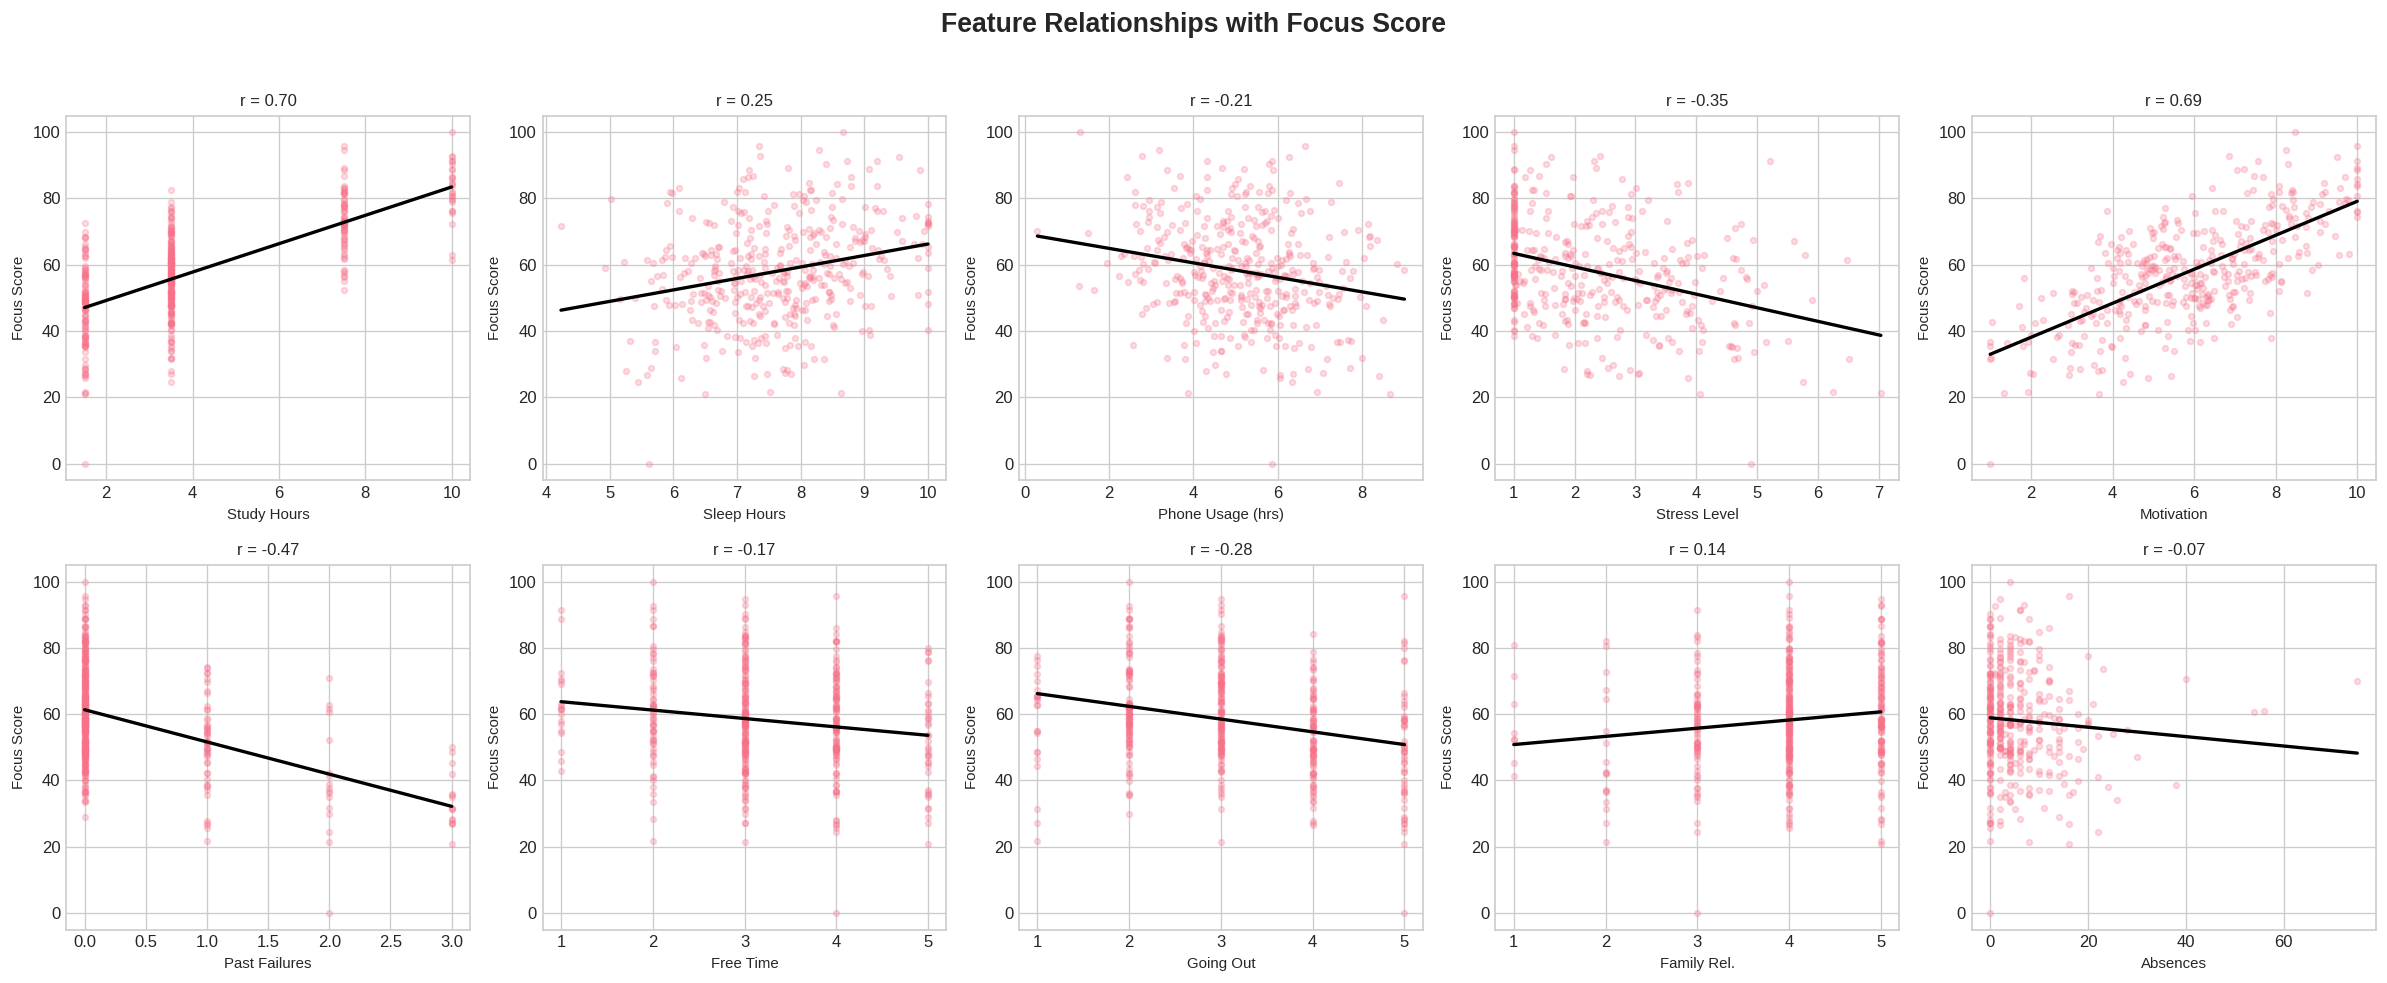

In [1]:
feature_cols = ['study_hours','sleep_hours','phone_usage_hrs','stress_level',
                'motivation_level','failures','freetime','goout','famrel','absences']
feature_labels = ['Study Hours','Sleep Hours','Phone Usage (hrs)','Stress Level',
                   'Motivation','Past Failures','Free Time','Going Out','Family Rel.','Absences']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Feature Relationships with Focus Score', fontsize=16, fontweight='bold', y=1.02)

for ax, feat, label in zip(axes.flat, feature_cols, feature_labels):
    ax.scatter(df[feat], df['focus_score'], alpha=0.25, s=12)
    m, b = np.polyfit(df[feat], df['focus_score'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m*x_line + b, 'k-', linewidth=2)
    corr = df[feat].corr(df['focus_score'])
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Focus Score', fontsize=9)
    ax.set_title(f'r = {corr:.2f}', fontsize=10)

plt.tight_layout()
plt.show()

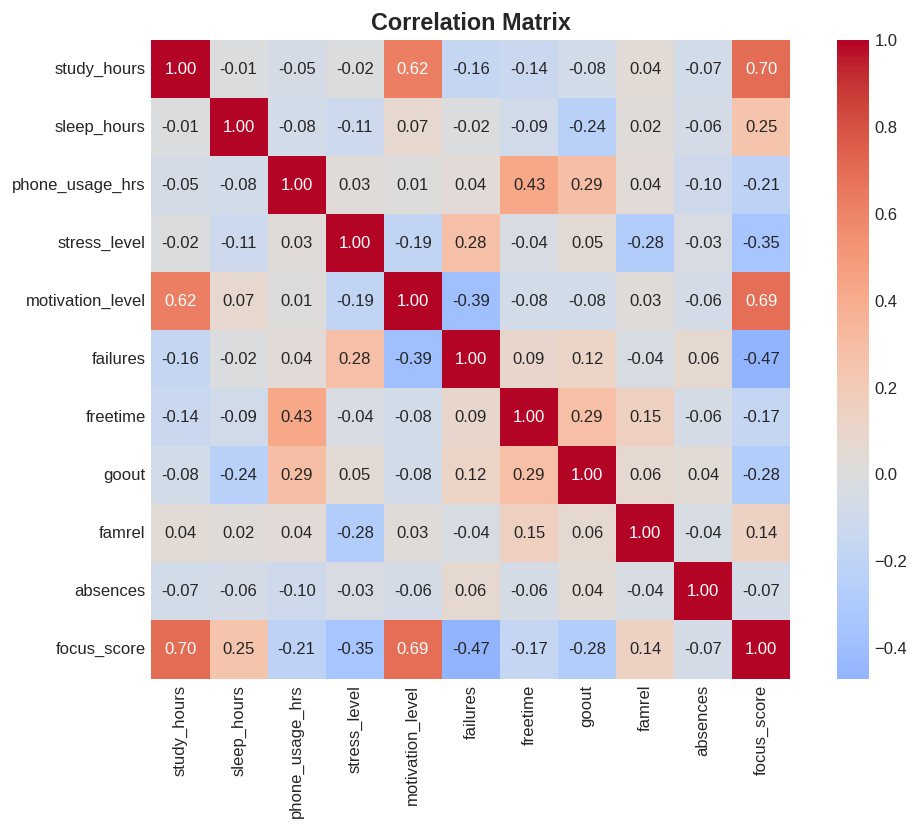

Correlations with focus_score, sorted:
study_hours         0.698
motivation_level    0.689
sleep_hours          0.251
famrel               0.144
absences            -0.074
freetime            -0.165
phone_usage_hrs     -0.210
goout               -0.279
stress_level        -0.349
failures            -0.471
dtype: float64


In [1]:
plt.figure(figsize=(9,7))
corr_matrix = df[feature_cols + ['focus_score']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlations with focus_score, sorted:")
print(df[feature_cols].corrwith(df['focus_score']).sort_values(ascending=False).round(3))